In [ ]:
%pip install opencv-python imbalanced-learn

In [14]:

# Diabetic Retinopathy Detection using CNN    Messidor-2


import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import shuffle

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam




In [15]:

# Step 1: Load the CSV dataset

csv_path     = r"C:\Users\Pc\Downloads\Messidor-2\messidor_data.csv"
image_folder = r"C:\Users\Pc\Downloads\Messidor-2\messidor-2\messidor-2\preprocess"

df = pd.read_csv(csv_path)

print("Dataset Loaded Successfully")
print(f"Total records : {len(df)}")
print(df.head())


Dataset Loaded Successfully
Total records : 1744
                      id_code  diagnosis  adjudicated_dme  \
0  20051020_43808_0100_PP.png          0                0   
1  20051020_43832_0100_PP.png          1                0   
2  20051020_43882_0100_PP.png          1                0   
3  20051020_43906_0100_PP.png          2                1   
4  20051020_44261_0100_PP.png          0                0   

   adjudicated_gradable  
0                     1  
1                     1  
2                     1  
3                     1  
4                     1  


In [16]:

# Step 2: Create binary labels
#   diagnosis 0   No DR  (label 0)
#   diagnosis 1-4  DR present (label 1)

df["binary_label"] = df["diagnosis"].apply(lambda x: 0 if x == 0 else 1)

print("\nClass Distribution Before Balancing:")
print(df["binary_label"].value_counts())
print(f"  No DR  (0): {(df['binary_label'] == 0).sum()}")
print(f"  DR     (1): {(df['binary_label'] == 1).sum()}")



Class Distribution Before Balancing:
binary_label
0    1017
1     727
Name: count, dtype: int64
  No DR  (0): 1017
  DR     (1): 727


In [17]:

# Step 3: Load and preprocess images
#   - Resize to IMG_SIZE x IMG_SIZE
#   - Normalize pixel values to [0, 1]

IMG_SIZE = 128

images = []
labels = []

print("Loading Images...")

for index, row in tqdm(df.iterrows(), total=len(df)):

    # Filename already includes extension (e.g. 20051020_43808_0100_PP.png)
    image_name = str(row["id_code"])
    image_path = os.path.join(image_folder, image_name)

    if not os.path.exists(image_path):
        continue

    img = cv2.imread(image_path)

    if img is None:
        continue

    # Resize to fixed dimensions
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

    # Normalize pixel values to [0, 1]
    img = img / 255.0

    images.append(img)
    labels.append(row["binary_label"])

X = np.array(images)
y = np.array(labels)

print(f"\nImages Loaded: {len(X)}")
print(f"X shape: {X.shape}    y shape: {y.shape}")


Loading Images...


100%|██████████| 1744/1744 [00:18<00:00, 92.40it/s] 



Images Loaded: 1744
X shape: (1744, 128, 128, 3)   y shape: (1744,)


In [18]:

# Step 4: Shuffle and apply SMOTE for class balancing
#
# SMOTE (Synthetic Minority Over-sampling Technique)
# generates synthetic samples for the minority class so
# that both classes are equally represented during training.
# SMOTE requires 2-D input, so images are flattened first,
# then reshaped back to (H, W, C) after resampling.


X, y = shuffle(X, y, random_state=42)

# Flatten: (N, 128, 128, 3)  (N, 49152)
X_flat = X.reshape(X.shape[0], -1)

print("Applying SMOTE...")
smote = SMOTE(random_state=42)
X_bal_flat, y_bal = smote.fit_resample(X_flat, y)

# Restore image shape: (N, 49152)  (N, 128, 128, 3)
X_bal = X_bal_flat.reshape(X_bal_flat.shape[0], IMG_SIZE, IMG_SIZE, 3)

print("\nClass Distribution After SMOTE:")
print(pd.Series(y_bal).value_counts())
print(f"Total balanced samples: {len(X_bal)}")


Applying SMOTE...

Class Distribution After SMOTE:
1    1017
0    1017
Name: count, dtype: int64
Total balanced samples: 2034


In [6]:

# Step 5: Convert labels to one-hot and split dataset
#   80 % training    20 % testing


y_cat = to_categorical(y_bal, num_classes=2)

X_train, X_test, y_train, y_test = train_test_split(
    X_bal, y_cat,
    test_size=0.2,
    random_state=42,
    stratify=y_cat
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")


Training samples : 1627
Testing  samples : 407


In [19]:

# Step 6: Build 10-Layer CNN Architecture
#
# Layer count (10 layers):
#   1. Input
#   2. Conv2D 32  + ReLU
#   3. MaxPooling2D
#   4. Conv2D 64  + ReLU
#   5. MaxPooling2D
#   6. Conv2D 128 + ReLU
#   7. MaxPooling2D
#   8. Flatten
#   9. Dense 128 + ReLU
#  10. Output Dense 2 + Softmax
#
# Dropout is added after Dense for regularization (not
# counted as a main layer per the brief's architecture).
# padding='same' preserves spatial dimensions after conv.


model = Sequential([
    Input(shape=(IMG_SIZE, IMG_SIZE, 3)),

    # Block 1 – 32 filters
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Block 2 – 64 filters
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Block 3 – 128 filters
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Fully connected head
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),          # Regularization – reduces overfitting

    # Output layer: 2 neurons (No DR / DR), softmax probability
    Dense(2, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,938 (16.36 MB)

 Trainable params: 4,287,938 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:

# Step 7: Train the model


EPOCHS     = 15
BATCH_SIZE = 32

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)


Epoch 1/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 23s 413ms/step - accuracy: 0.5138 - loss: 0.6933 - val_accuracy: 0.6339 - val_loss: 0.6883
Epoch 2/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 21s 422ms/step - accuracy: 0.5636 - loss: 0.6835 - val_accuracy: 0.6437 - val_loss: 0.6752
Epoch 3/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 402ms/step - accuracy: 0.6398 - loss: 0.6606 - val_accuracy: 0.6290 - val_loss: 0.6553
Epoch 4/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 426ms/step - accuracy: 0.6521 - loss: 0.6421 - val_accuracy: 0.6339 - val_loss: 0.6489
Epoch 5/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 399ms/step - accuracy: 0.6730 - loss: 0.6279 - val_accuracy: 0.6339 - val_loss: 0.6452
Epoch 6/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 432ms/step - accuracy: 0.6687 - loss: 0.6243 - val_accuracy: 0.6314 - val_loss: 0.6478
Epoch 7/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 40s 405ms/step - accuracy: 0.6595 - loss: 0.6294 - val_accuracy: 0.6511 - val_loss: 0.6307
Epoch 8/15
51/51 ━━━━━━━━━━━━━━━━━━━━ 22s 428ms/step - accuracy: 0.6767 - loss: 0.6049 - val_accu

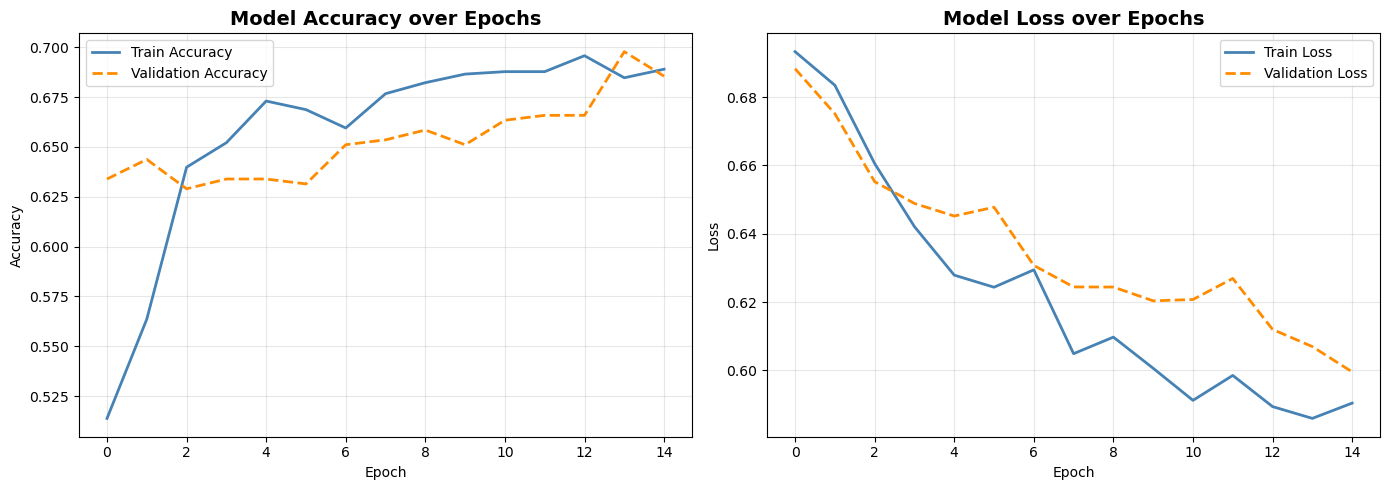

Training curves saved to training_curves.png


In [20]:

# Step 8: Plot Training and Validation Curves

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Accuracy ---
axes[0].plot(history.history['accuracy'],     label='Train Accuracy',      color='steelblue',  linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='darkorange', linewidth=2, linestyle='--')
axes[0].set_title('Model Accuracy over Epochs', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Loss ---
axes[1].plot(history.history['loss'],     label='Train Loss',      color='steelblue',  linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='darkorange', linewidth=2, linestyle='--')
axes[1].set_title('Model Loss over Epochs', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved to training_curves.png")


In [10]:

# Step 9: Evaluate the model on the test set


loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {accuracy * 100:.2f}%")

# Predictions
predictions = model.predict(X_test)
y_pred = np.argmax(predictions, axis=1)
y_true = np.argmax(y_test,      axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["No DR", "DR"]))


Test Loss     : 0.5995
Test Accuracy : 68.55%
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 128ms/step

Classification Report:
              precision    recall  f1-score   support

       No DR       0.69      0.68      0.68       203
          DR       0.68      0.69      0.69       204

    accuracy                           0.69       407
   macro avg       0.69      0.69      0.69       407
weighted avg       0.69      0.69      0.69       407



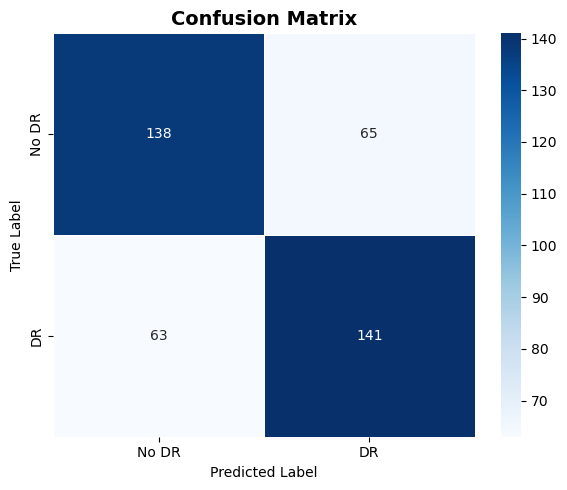

Confusion matrix saved to confusion_matrix.png


In [21]:

# Step 10: Confusion Matrix


cm = confusion_matrix(y_true, y_pred)
labels_cm = ["No DR", "DR"]

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels_cm,
    yticklabels=labels_cm,
    linewidths=0.5
)
plt.title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Confusion matrix saved to confusion_matrix.png")


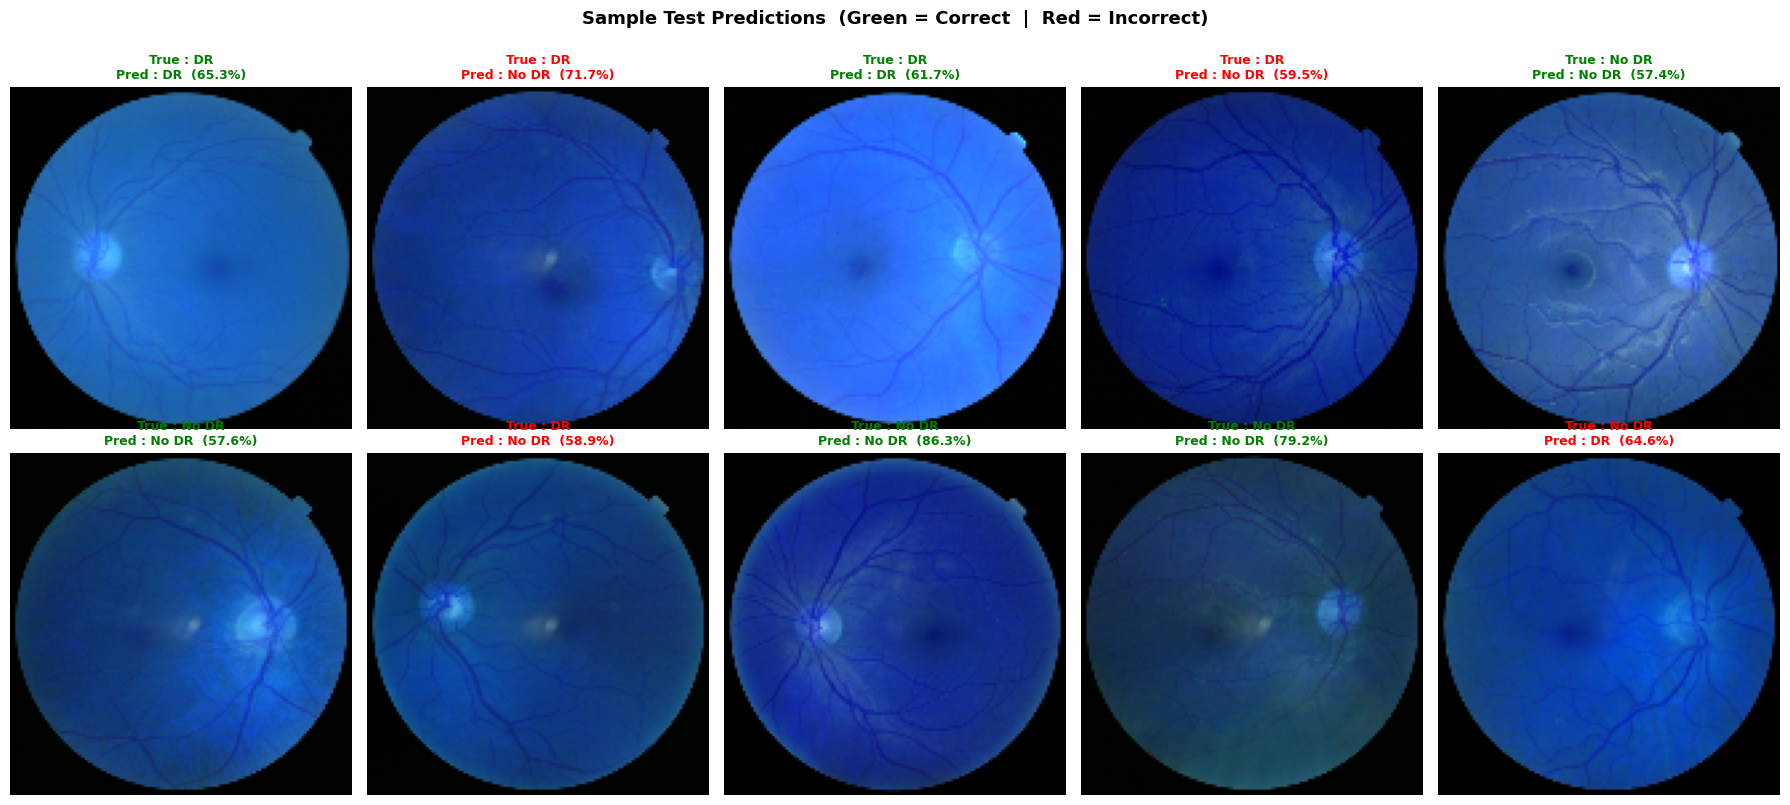

Sample predictions saved to sample_predictions.png


In [22]:

# Step 11: Sample Test Predictions
#   Display 10 test images with true vs predicted labels


class_names = {0: "No DR", 1: "DR"}

# Pick 10 evenly spaced samples from the test set
sample_indices = np.linspace(0, len(X_test) - 1, 10, dtype=int)

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
axes = axes.flatten()

for i, idx in enumerate(sample_indices):
    img_display = X_test[idx]          # already normalized [0,1]
    true_label  = y_true[idx]
    pred_label  = y_pred[idx]
    confidence  = predictions[idx][pred_label] * 100

    axes[i].imshow(img_display)
    axes[i].axis('off')

    color = 'green' if true_label == pred_label else 'red'
    axes[i].set_title(
        f"True : {class_names[true_label]}\nPred : {class_names[pred_label]}  ({confidence:.1f}%)",
        fontsize=9,
        color=color,
        fontweight='bold'
    )

plt.suptitle('Sample Test Predictions  (Green = Correct  |  Red = Incorrect)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample predictions saved to sample_predictions.png")


In [23]:

# Step 12: Save the trained model (native Keras format)


model.save("messidor_dr_cnn.keras")
print("Model saved successfully as  messidor_dr_cnn.keras")


Model saved successfully as  messidor_dr_cnn.keras
